In [1]:
import numpy as np
import pandas as pd
from tqdm import trange
import utm
import time
import os
import pickle as pkl
import inspect

from obspy import read

from obspy.clients.fdsn import Client

# import UTCDateTime from obspy
from obspy.core.utcdatetime import UTCDateTime as UTC
from obspy.core.event.catalog import read_events
import datetime
import matplotlib.pyplot as plt

from haversine import haversine, Unit
import math

from seismo_functions import load_tt

from multitaper import mtspec
import scipy
import scipy.signal as signal
import scipy.linalg as linalg
import multitaper.utils as utils


In [2]:
cat_dir = "/Users/ivandevert/projects/ridgecrest2019/data/catalogs/"
eloc_catalog_path = "/Users/ivandevert/projects/ridgecrest2019/data/trugman_ridgecrest2019_relocated_catalog.txt"
figure_save_dir = "/Users/ivandevert/projects/ridgecrest2019/figures/example_spectra/"
spectra_save_dir = "/Users/ivandevert/projects/ridgecrest2019/spectra/"

# Program parameters
tbuf = -0.15                # time relative to pick for signal window
twin = 1.5                  # length of desired signal and noise windows (s)
Fs = 100                    # desired sampling rate for output spectra
phase = 'P'

dt = 1 / Fs
nwin = int(twin * Fs)
nf = int(nwin / 2 + 1)
fN = Fs / 2
# 


# Multitaper parameters
nw = 3.5                    # time bandwidth product
kspec = 5                   # number of tapers
nfft = int(2*twin*Fs + 1)   # number of FFT points to pad to
iadapt = 0                  # multitaper method: 0=adaptive, 1=unweighted, 2=wt by the eigenvalue of DPSS (see docs)


plot_example_spectra = True
plot_example_percentage = 0.001

# variable time window
min_twin = 1.5
max_twin = 4.5
d_twin = 0.25
M_min_twin = 3.5
M_max_twin = 4.5

# each of these dirs contains folders, one per event, containing seismograms, one per station
# dirs_containing_events = [
#     "/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M3above/",
#     "/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M2.0to2.5/",
# ]
dirs_containing_events = [
    '/Volumes/LaCie/data/ridgecrest2019/RC_M3above/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M2.5to3.0/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M2.0to2.5/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M1.8to2.0/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M1.6to1.8/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M1.4to1.6/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M1.2to1.4/',
    '/Volumes/LaCie/data/ridgecrest2019/RC_M1.0to1.2/']

# earthquake location catalog (Trugman 2020)
eloc_catalog_path = "/Users/ivandevert/projects/ridgecrest2019/data/trugman_ridgecrest2019_relocated_catalog.txt"

p_traveltime_path = "/Users/ivandevert/projects/ridgecrest2019/data/out.ttP"
s_traveltime_path = "/Users/ivandevert/projects/ridgecrest2019/data/out.ttS"



In [3]:

def obspy_catalog_to_df(catalog, client_format='SCEDC'):

    event_name = []
    station_name = []
    pick_phase = []
    pick_time = []
    


    for i in trange(len(catalog)):
        ev = catalog[i]
        ename = int(ev.resource_id.id.split('=')[-1])

        picks = ev.picks
        sname = [[]] * len(picks)
        pphase = [[]] * len(picks)
        ptime = [[]] * len(picks)
        for p, pick in enumerate(picks):
            sname[p] = pick.waveform_id.id
            pphase[p] = pick.phase_hint
            ptime[p] = (np.datetime64(pick.time.datetime, 'ms') - np.datetime64(ev.origins[0].time, 'ms')).astype(float) * 1E-3
        event_name += [ename] * len(picks)
        station_name += sname
        pick_phase += pphase
        pick_time += ptime

    df = pd.DataFrame(
        {
            'event_name':       event_name,
            'station_name':     station_name,
            'pick_phase':       pick_phase,
            'pick_time':        pick_time
        }
    )
    
    # sort by event_name
    df = df.sort_values(by='event_name').reset_index(drop=True)

    return df

# compute distances between events and stations in km
def geo_distance(lat1, lon1, lat2, lon2):
    earth_radius = 6371.0
    # Convert all angles to radians
    lat1_r = np.deg2rad(lat1)
    lon1_r = np.deg2rad(lon1)
    lat2_r = np.deg2rad(lat2)
    lon2_r = np.deg2rad(lon2)
    # Calculate the distance
    dp = np.cos(lat1_r) * np.cos(lat2_r) * np.cos(lon1_r - lon2_r) + np.sin(lat1_r) * np.sin(lat2_r)
    angle = np.arccos(dp)
    return earth_radius * angle

def merge_picks(df, df_picks):

    DF = df.copy()
    DF['sloc'] = ['.'.join(el.split('.')[:-1]) for el in DF['station_name'].values]

    print("Matching picks to event and station pairs...", end='')
    # Separate P and S picks
    df_p = df_picks.copy()
    df_s = df_picks.copy()

    # drop rows with 'S' pick_phase from df_p
    df_p = df_p[df_p['pick_phase'] == 'P'].reset_index(drop=True)
    df_s = df_s[df_s['pick_phase'] == 'S'].reset_index(drop=True)

    # rename pick_time to pick_p or pick_s
    df_p.rename(columns={'pick_time': 'p_arrival'}, inplace=True)
    df_s.rename(columns={'pick_time': 's_arrival'}, inplace=True)

    # drop pick_phase
    df_p.drop(columns=['pick_phase'], inplace=True)
    df_s.drop(columns=['pick_phase'], inplace=True)

    # apply picks to location, not just channel
    df_p = df_p.groupby(['event_name', 'sloc'], as_index=False)[['p_arrival']].agg(list)
    df_s = df_s.groupby(['event_name', 'sloc'], as_index=False)[['s_arrival']].agg(list)
    df_p['p_arrival'] = df_p['p_arrival'].apply(np.nanmean)
    df_s['s_arrival'] = df_s['s_arrival'].apply(np.nanmean)

    # merge both into df
    df_out = pd.merge(DF, df_p, how='left', on=['event_name', 'sloc'])
    df_out = pd.merge(df_out, df_s, how='left', on=['event_name', 'sloc'])

    # drop sloc column
    df_out.drop(columns=['sloc'], inplace=True)

    # fill NaN with -99.0 in p_arrival and s_arrival
    df_out.fillna(-99.0, inplace=True)

    print("Done.")
    return df_out

# assign approximate p and s arrival times based on travel time tables

def get_pick_estimate(X, Y, TT, distance, depth):
    """Get an estimated pick time for a given event-station distance 
    and event depth using a travel time table.

    This is designed to interpolate travel times from Peter's traveltime
    codes. X, Y, and TT are np.ndarray objects output from the load_tt()
    function in stressdrop_file_IO.py. See interpolate_grid() for more 
    detailed information.

    Args:
        X (np.ndarray): Distance spacing array
        Y (np.ndarray): Depth spacing array
        TT (np.ndarray): Estimated travel times for given X and Y points
        distance (float): Event-station distance (km or degrees)
        depth (float): Event depth (km)

    Returns:
        Tinterp (float): Estimated travel time

    Sources:

    Last Modified:
        2024-02-06
    """

    dx = X[1] - X[0]
    dy = Y[1] - Y[0]
    
    try:
        # get indices of the element to the left of the value in the X and Y
        # directions. Ex: for X = [0, 1, 2, 3] and distance = 1.12, ix = 1
        ix = np.abs(X - distance).argmin()
        iy = np.abs(Y - depth).argmin()
        if distance < (ix * dx): ix -= 1
        if depth <= (iy * dy): iy -= 1

        # get left and right element relative to actual value
        xx = X[ix:ix+2]
        yy = Y[iy:iy+2]
        
        # get 4 elements surrounding actual value
        tt = TT[ix:ix+2,iy:iy+2]

        # notation: T0p: T at x[0], Yp or T(x[0], Yp)
        # Tij = T(xi, yj)
        T0p = ((tt[0,1]-tt[0,0]) / dy ) * (depth - yy[0]) + tt[0,0] #top
        T1p = ((tt[1,1]-tt[1,0]) / dy ) * (depth - yy[0]) + tt[1,0] #bottom
        Tp0 = ((tt[1,0]-tt[0,0]) / dx ) * (distance - xx[0]) + tt[0,0] #left
        Tp1 = ((tt[1,1]-tt[0,1]) / dx ) * (distance - xx[0]) + tt[0,1] #right

        # interpolate along midlines
        Tpx = ((T1p - T0p)/ dx ) * (distance - xx[0]) + T0p
        Tpy = ((Tp1 - Tp0)/ dy ) * (depth - yy[0]) + Tp0
        
        Tinterp = (Tpx+Tpy)/2
    except Exception as E:
        print(E)
        print(f"depth: {depth:.2f}")
        print(f"distance: {distance:.2f}")
        print(f"xx: {xx}")
        print(f"yy: {yy}")
        print(f"tt: {tt}")
        Tinterp = -99999.0
    return Tinterp


def mtspec_helper(x, nw, kspec, dt, nfft, iadapt, vn, lamb):
    # assumptions:
    # 1) x is real
    # 2) nfft is odd (nwin is even)

    npts = len(x)

    x = x[:, np.newaxis]

    nf = int((nfft+1)/2)
    f = scipy.fft.fftfreq(nfft, dt)
    df = f[1] - f[0]

    x = signal.detrend(x, axis=0, type='constant')
    xvar = np.var(x)

    yk, sk  = utils.eigenspec(x, vn, lamb, nfft)

    spec, se, wt = utils.adaptspec(yk, sk, lamb, iadapt)
    sscal = np.sum(spec)*df
    sscal = xvar/sscal
    spec  = sscal*spec

    freq     = np.zeros((nf,1), dtype=float)
    freq     = f[0:nf]


    # spec = np.zeros((nf,1), dtype=float)
    spec = spec[0:nf,0]
    spec[0:nf]   = 2.0 * spec[0:nf]
    spec[0]      = 0.5 * spec[0]
    
    return freq, spec

def get_time_window_length_peter(emag, minTW, maxTW, minmag, maxmag, dTW):
    if emag <= minmag:
        return minTW
    elif emag >= maxmag:
        return maxTW
    else:
        # interpolate the value between minTW and maxTW, then round to the nearest dTW
        return np.round((emag - minmag) / (maxmag - minmag) * (maxTW - minTW) / dTW) * dTW + minTW


# simplified variable time window length: assign time window lengths to 
# each record based on emag. emag <=M_min_twin should have twin = M_min_twin
# emag >= M_max_twin should have twin = M_max_twin, emag between should be 
# assigned a twin between M_min_twin and M_max_twin
def get_time_window_length(emag, min_twin, max_twin, M_min_twin, M_max_twin, d_twin):
    ntwin = int((max_twin - min_twin) / d_twin + 1)
    if emag <= M_min_twin:
        return min_twin, 0
    elif emag >= M_max_twin:
        return max_twin, int(ntwin-1)
    else:
        dMwin = (M_max_twin - M_min_twin) / (ntwin - 2)
        n = np.ceil((emag - M_min_twin) / dMwin)
        twin = d_twin * n + min_twin
        return twin, int(n)

Seismograms file structure:

```
dirs_containing_events[0]/
├── event_names[0]/
│   ├── record.ms
│   ├── record.ms
│   ├── ...
│   └── record.ms
├── event_names[1]/
│   ├── record.ms
│   ├── record.ms
│   ├── ...
│   └── record.ms
├── ...
└── event_names[N]/
│   ├── record.ms
│   ├── record.ms
│   ├── ...
│   └── record.ms
dirs_containing_events[1]/
├── event_names[0]/
├── event_names[1]/
├── ...
└── event_names[N]/
...
```

Record names have the format:
```
STA.NET.CHA.LOC.eyr.eday.etime.ms
```

Event names are integers (for this dataset)

In [4]:
# First, get all the dirs of the events
event_dirs = []
for d in dirs_containing_events:
    event_dirs += [os.path.join(d,f)+"/" for f in os.listdir(d) if os.path.isdir(os.path.join(d,f))]
# event_names = [event_dirs[i].split('/')[-1] for i in range(len(event_dirs))]

# Get all paths of seismograms
seismogram_paths = []
for i in trange(len(event_dirs)):
    d = event_dirs[i]
    seismogram_paths += [os.path.join(d,f) for f in os.listdir(d) if f.endswith('.ms')]

print(f"Discovered {len(seismogram_paths):,} seismograms of {len(event_dirs):,} events")

# Determine event name and station name for each entry in seismogram_paths
event_names, record_names = np.array(
    [fp.split('/')[-2:] for fp in seismogram_paths]
    ).T
sta, net, cha, loc, syr, jday, hms, event_name, ms = np.array(
    [record_names[i].split('.') for i in range(len(record_names))]
    ).T

event_names = np.array(event_names, dtype=int)
station_names = np.array(
    ['.'.join([net[i], sta[i], loc[i], cha[i]]) for i in range(len(sta))]
    )

df_files = pd.DataFrame(
    {
        'event_name':       event_names,
        'station_name':     station_names,
        'seismogram_path':  seismogram_paths
    }
)

ev_files = df_files.groupby(['event_name'], as_index=False)[['station_name', 'seismogram_path']].agg(list)

100%|██████████| 12943/12943 [02:33<00:00, 84.13it/s]


Discovered 3,351,167 seismograms of 12,943 events


Download event catalog and any available picks

In [5]:
starttime = '2019-07-03T00:00:00.000000Z'
endtime = '2019-07-19T00:00:00.000000Z'
minmagnitude = 0.95
maxmagnitude = 9.0
minlongitude = -118.0
maxlongitude = -117.0
minlatitude = 35.0
maxlatitude = 37.0

bulk_dt_hours = 6

# split into days
t0_utc = UTC(starttime)
t1_utc = UTC(endtime)
iters = int(np.ceil((t1_utc - t0_utc) / (3600*bulk_dt_hours)))

clients = ["SCEDC", "IRIS"]

# check if catalog already exists
download_catalog = False
for cname in clients:
    if not os.path.exists(f"{cat_dir}picks_{cname.lower()}.pkl"):
        download_catalog = True
        print("will download catalog")

if download_catalog:
    for cname in clients:
        print(f"Downloading data from client {cname}...")
        client = Client(cname)
        cat = None
        for i in trange(int(iters)):
            t0 = t0_utc + i*3600*bulk_dt_hours
            t1 = t0_utc + (i+1)*3600*bulk_dt_hours
            try:
                cat_part = client.get_events(
                    starttime=str(t0),
                    endtime=str(t1),
                    minmagnitude=minmagnitude,
                    maxmagnitude=maxmagnitude,
                    minlongitude=minlongitude,
                    maxlongitude=maxlongitude,
                    minlatitude=minlatitude,
                    maxlatitude=maxlatitude,
                    includearrivals=True
                    )
                if cat:
                    cat += cat_part
                else:
                    cat = cat_part
            except Exception as e:

                # no data error (no events in timeframe)
                if e.status_code==204:
                    pass
                else:
                    print(e)

        # takes sooooo long
        # cat.write(cat_dir + f'catalog_{cname.lower()}.xml', format='quakeml')

        df_picks = obspy_catalog_to_df(cat)
        with open(f"{cat_dir}picks_{cname.lower()}.pkl", 'wb') as fs:
            pkl.dump(df_picks, fs)

df_picks = None

for cname in clients:
    with open(f"{cat_dir}picks_{cname.lower()}.pkl", 'rb') as fs:
        if df_picks is not None:
            df_picks = pd.concat([df_picks, pkl.load(fs)])
        else:
            df_picks = pkl.load(fs)
df_picks = df_picks.reset_index(drop=True)
df_picks['event_name'] = df_picks['event_name'].astype(int)
df_picks['sloc'] = ['.'.join(el.split('.')[:-1]) for el in df_picks['station_name'].values]

print(f"{len(df_picks):,} picks loaded")
# this might have multiple entries for the same record/phase combo

698,811 picks loaded


In [6]:
# download station information, or load from file

download_stations = False
if not os.path.exists(f"{cat_dir}inv_ridgecrest.pkl"):
    download_stations = True
    print("will download station information")
    raise NotImplementedError("not written yet")
else:
    with open(f"{cat_dir}inv_ridgecrest.pkl", 'rb') as fs:
        df_stations = pkl.load(fs)
    print(f"Station metadata loaded from file for {len(df_stations):,} stations")
df_stations['sloc'] = ['.'.join(el.split('.')[:-1]) for el in df_stations['station_name'].values]

Station metadata loaded from file for 11,441 stations


In [7]:

# Load Trugman (2020) earthquake relocations
df_locations = pd.read_csv(
    eloc_catalog_path,
    sep=r'\s+',
    skiprows=28,
    header=None,
    names=[
        'event_name', 'ymd', 'hms', 'emag', 'elon', 'elat', 'edep', 'relocated'
        ],
    dtype={
        'event_name': int,
        'ymd': str,
        'hms': str,
        'emag': float,
        'elon': float,
        'elat': float,
        'edep': float,
        'relocated': bool,
        }
)
df_locations['etime'] = df_locations['ymd'] + 'T' + df_locations['hms'] + "Z"
df_locations['etime'] = [UTC(el).datetime for el in df_locations['etime'].values]
df_locations.drop(columns=['ymd', 'hms'], inplace=True)
# sort by event_name
df_locations = df_locations.sort_values(by='event_name').reset_index(drop=True)

print(f"Metadata for {len(df_locations):,} events loaded from Trugman (2020)")

Metadata for 12,943 events loaded from Trugman (2020)


In [8]:
# Now, I have four dataframes:
# 1) df_files: all downloaded seismograms (event_name, station_name)
# 2) df_picks: all cataloged picks (event_name, station_name, pick_phase, pick_time)
# 3) df_locations: all event locations (event_name, emag, elon, elat, edep, etime)
# 4) df_stations: all station information (station_name, slat, slon, sele, local_depth, sample_rate, sdip, sazi)
#
# 
df = df_files.copy()
ev_dep = ['event_name']
st_dep = ['station_name']
rec_dep = ['seismogram_path']
loc_dep = []
cha_dep = []
print(f"Number of seismograms loaded: {len(df):,}")

# Merge picks into df
df = merge_picks(df, df_picks)
rec_dep += ['p_arrival', 's_arrival']
print(f"Number of seismograms with P picks: {len(df[df['p_arrival']!=-99.0]):,} ({len(df[df['p_arrival']!=-99.0])/len(df)*100:.2f}%)")
print(f"Number of seismograms with S picks: {len(df[df['s_arrival']!=-99.0]):,} ({len(df[df['s_arrival']!=-99.0])/len(df)*100:.2f}%)")

# Add magnitude, event location, and origin times to df
print("Adding event magnitude, location, and origin times...", end='')
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+rec_dep].agg(list)
df_ev = pd.merge(df_ev, df_locations, how='left', on=ev_dep)
ev_dep += ['emag', 'elon', 'elat', 'edep', 'relocated', 'etime']
df = df_ev.explode(st_dep+rec_dep).reset_index(drop=True)
print("Done.")
print(f"Number of events loaded from Trugman (2020): {len(df_locations):,}")

# Merge station information into df
print("Adding station location and information...", end='')
df_st = df.groupby(st_dep, as_index=False)[ev_dep+rec_dep].agg(list)
df_st = pd.merge(df_st, df_stations, how='left', on=st_dep)
st_dep += ['slat', 'slon', 'sele', 'local_depth', 'sample_rate', 'sdip', 'sazi']
df = df_st.explode(ev_dep+rec_dep).reset_index(drop=True)
print("Done.")
print(f"Number of stations/channels loaded from downloaded inventory: {len(df_stations):,}")
print(f"Number of stations/channels used: {len(df_st):,}")

# Add station-event distance
df['rec_dist'] = geo_distance(
    df['elat'].values.astype(float), 
    df['elon'].values.astype(float), 
    df['slat'].values.astype(float), 
    df['slon'].values.astype(float)
)
rec_dep += ['rec_dist']

df_ev = df.groupby(ev_dep, as_index=False)[st_dep+rec_dep].agg(list)
df_st = df.groupby(st_dep, as_index=False)[ev_dep+rec_dep].agg(list)

# # want to group such that each row is an event/location pair
# loc_dep = st_dep.copy()
# cha_dep = ['station_name', 'sample_rate', 'sdip', 'sazi']

# for el in ['station_name', 'sample_rate', 'sdip', 'sazi']:
#     loc_dep.remove(el)

# df_loc = df.groupby(loc_dep, as_index=False)[ev_dep+rec_dep+cha_dep].agg(list)


Number of seismograms loaded: 3,351,167
Matching picks to event and station pairs...Done.
Number of seismograms with P picks: 1,359,112 (40.56%)
Number of seismograms with S picks: 991,640 (29.59%)
Adding event magnitude, location, and origin times...Done.
Number of events loaded from Trugman (2020): 12,943
Adding station location and information...Done.
Number of stations/channels loaded from downloaded inventory: 11,441
Number of stations/channels used: 531


In [12]:
# construct a picks sparse matrix pick_p, pick_s. Each row represents an event, each column a station. 
# Indices represent the index of the event/station pair

from scipy.sparse import csr_matrix

picks_ev = df_ev['event_name'].unique().astype(int)
picks_ev.sort()

sloc = np.array(['.'.join(el.split('.')[:-1]) for el in df_st['station_name'].values])

picks_st = np.unique(sloc)
picks_st.sort()

df_picks_sloc = df_picks['sloc'].unique()

df_picks_p = df[df['p_arrival']!=-99.0].reset_index(drop=True)[['station_name', 'event_name', 'p_arrival']]
df_picks_s = df[df['s_arrival']!=-99.0].reset_index(drop=True)[['station_name', 'event_name', 's_arrival']]

df_picks_p['sloc'] = np.array(['.'.join(el.split('.')[:-1]) for el in df_picks_p['station_name'].values])
df_picks_s['sloc'] = np.array(['.'.join(el.split('.')[:-1]) for el in df_picks_s['station_name'].values])

# drop station_name columns
df_picks_p.drop('station_name', axis=1, inplace=True)
df_picks_s.drop('station_name', axis=1, inplace=True)

# some rows are repeated, need to remove those
df_picks_p = df_picks_p.drop_duplicates(subset=['event_name', 'sloc'], keep='first').reset_index(drop=True)
df_picks_s = df_picks_s.drop_duplicates(subset=['event_name', 'sloc'], keep='first').reset_index(drop=True)

# rename p_arrival, s_arrival cols to pick_time
df_picks_p.rename(columns={'p_arrival': 'pick_time'}, inplace=True)
df_picks_s.rename(columns={'s_arrival': 'pick_time'}, inplace=True)

icol = np.empty(len(df_picks_p), dtype=int)
irow = np.empty(len(df_picks_p), dtype=int)
val = np.empty(len(df_picks_p), dtype=float)
n = 0
for i in range(len(df_picks_p)):
    row = np.argwhere(picks_ev == df_picks_p['event_name'].values[i])
    col = np.argwhere(picks_st == df_picks_p['sloc'].values[i])
    if row.size>0 and col.size>0:
        icol[n] = row[0][0]
        irow[n] = col[0][0]
        val[n] = df_picks_p['pick_time'].values[i]
        n += 1
icol = icol[:n]
irow = irow[:n]
val = val[:n]
pick_p = csr_matrix((val, (icol, irow)), shape=(len(picks_ev), len(picks_st)))

# for i in range(len(val)):
#     assert pick_p[icol[i], irow[i]] == val[i], f"{i}, {val[i]}, {pick_p[icol[i], irow[i]]}, {icol[i]}, {irow[i]}"


icol = np.empty(len(df_picks_s), dtype=int)
irow = np.empty(len(df_picks_s), dtype=int)
val = np.empty(len(df_picks_s), dtype=float)
n = 0
for i in range(len(df_picks_s)):
    row = np.argwhere(picks_ev == df_picks_s['event_name'].values[i])
    col = np.argwhere(picks_st == df_picks_s['sloc'].values[i])
    if row.size>0 and col.size>0:
        icol[n] = row[0][0]
        irow[n] = col[0][0]
        val[n] = df_picks_s['pick_time'].values[i]
        n += 1
icol = icol[:n]
irow = irow[:n]
val = val[:n]
pick_s = csr_matrix((val, (icol, irow)), shape=(len(picks_ev), len(picks_st)))


# check to make sure picks are encoded correctly

# for i in range(len(df_picks_p)):
#     row = np.where(picks_ev == df_picks_p['event_name'].values[i])[0][0]
#     col = np.where(picks_st == df_picks_p['sloc'].values[i])[0][0]
#     assert pick_p[row, col] == df_picks_p['pick_time'].values[i]

# for i in range(len(df_picks_s)):
#     row = np.where(picks_ev == df_picks_s['event_name'].values[i])[0][0]
#     col = np.where(picks_st == df_picks_s['sloc'].values[i])[0][0]
#     assert pick_s[row, col] == df_picks_s['pick_time'].values[i]


# now, pick times can be quickly looked up in pick_p and pick_s by matching
# event_name to picks_ev and sloc to picks_st

In [13]:
# Load traveltime tables
X, Y, ttp = load_tt(p_traveltime_path)
X, Y, tts = load_tt(s_traveltime_path)

p_arrival_est = np.zeros(len(df))
s_arrival_est = np.zeros(len(df))

for i in range(len(df)):
    distance = df['rec_dist'].values[i]
    depth = df['edep'].values[i] + df['sele'].values[i]*0.001

    if depth <= 0: depth = 0.0001
    p_arrival_est[i] = get_pick_estimate(X, Y, ttp, distance, depth)
    s_arrival_est[i] = get_pick_estimate(X, Y, tts, distance, depth)

df['p_arrival_est'] = p_arrival_est
df['s_arrival_est'] = s_arrival_est

In [14]:
# print out some stats:

# number of records with no picks
n_0_picks = df[(df['p_arrival']==-99.0) & (df['s_arrival']==-99.0)]
print(f"Number of records with no picks: {len(n_0_picks):,} ({len(n_0_picks)/len(df)*100:.2f}%)")

# number of records with only a p-pick:
n_p_picks = df[(df['p_arrival']!=-99.0) & (df['s_arrival']==-99.0)]
print(f"Number of records with only a p-pick: {len(n_p_picks):,} ({len(n_p_picks)/len(df)*100:.2f}%)")

# number of records with only a s-pick:
n_s_picks = df[(df['p_arrival']==-99.0) & (df['s_arrival']!=-99.0)]
print(f"Number of records with only a s-pick: {len(n_s_picks):,} ({len(n_s_picks)/len(df)*100:.2f}%)")

# number of records with either a p- or s-pick:
n_1_picks = df[(df['p_arrival']!=-99.0) | (df['s_arrival']!=-99.0)]
print(f"Number of records with either a p- or s-pick: {len(n_1_picks):,} ({len(n_1_picks)/len(df)*100:.2f}%)")

# number of records with both picks:
n_2_picks = df[(df['p_arrival']!=-99.0) & (df['s_arrival']!=-99.0)]
print(f"Number of records with both picks: {len(n_2_picks):,} ({len(n_2_picks)/len(df)*100:.2f}%)")

# total records
print(f"Total number of records: {len(df):,}")

Number of records with no picks: 1,814,231 (54.14%)
Number of records with only a p-pick: 545,296 (16.27%)
Number of records with only a s-pick: 177,824 (5.31%)
Number of records with either a p- or s-pick: 1,536,936 (45.86%)
Number of records with both picks: 813,816 (24.28%)
Total number of records: 3,351,167


Compute spectra

In [ ]:
# # test some times to do operations
# pick_ev_dict = {eid: i for i, eid in enumerate(picks_ev)}
# pick_st_dict = {sid: i for i, sid in enumerate(picks_st)}

# N = 10000

# t0 = time.time()
# for i in range(len(seismogram_paths[:N])): 
#     ev_id = event_names[i]
#     st_id = station_names[i]
#     sloc = '.'.join(st_id.split('.')[:-1])

#     prow = np.argwhere(picks_ev == ev_id)
#     pcol = np.argwhere(picks_st == sloc)
#     if prow.size>0 and pcol.size>0:
#         pick = pick_p[prow[0], pcol[0]]

# print(f"Time to read picks: {(time.time() - t0) / N * 1000:.3f} ms  / iteration")

# t0 = time.time()
# for i in range(len(seismogram_paths[:N])): 
#     ev_id = event_names[i]
#     st_id = station_names[i]
#     sloc = '.'.join(st_id.split('.')[:-1])

#     pick = pick_p[pick_ev_dict[ev_id], pick_st_dict[sloc]]

# print(f"Time to read picks (dict lookup): {(time.time() - t0) / N * 1000:.3f} ms / iteration")

In [ ]:
# minTW = 1.5
# maxTW = 4.5
# dTW = 0.25
# scaleTW = 2.0
# outTW = 1.5

# Mref = 3.5
# c0 = 0.88
# c1 = 0.754

# delsigTW = 0.1
# kP = 0.38
# beta = 3464.0




# # generate 1000 random magnitudes mags between 1 and 7
# mags = np.random.uniform(3.0, 5.0, 1000)

# tw_len = np.zeros(len(mags))

# NTW = int((maxTW - minTW) / dTW + 1)
# print(f"NTW: {NTW}")

# for i in range(len(mags)):
#     if mags[i] > Mref:
#         qMw = mags[i]
#     else:
#         qMw = c0 + c1*mags[i]
#     qlogM0 = 1.5 * qMw + 9.1

#     logTmin = (1/3.0) * (np.log10(7.0/16) + qlogM0 - np.log10(delsigTW) - 6.0) - np.log10(kP*beta)
#     Tmin = 10**logTmin
#     Tmin = scaleTW * Tmin

#     for jj in range(NTW):
#         Tw_jj = np.real(jj) * dTW + minTW
#         # print(f"Tw_jj: {Tw_jj}")
#         if Tw_jj >= Tmin:
#             break

#     # print(f"Tw_jj: {Tw_jj}")
#     tw_len[i] = Tw_jj

# mags2 = np.random.uniform(3.0, 5.0, 1000)

# tw_len2 = [get_time_window_length(el, 1.5, 4.5, 3.5, 4.5, 0.25) for el in mags2]


# plt.figure()
# plt.scatter(mags, tw_len, c='k', s=1)
# # plt.scatter(mags2, tw_len2, c='r', s=1)
# plt.xlabel("Magnitude")
# plt.ylabel("twin")
# plt.show()

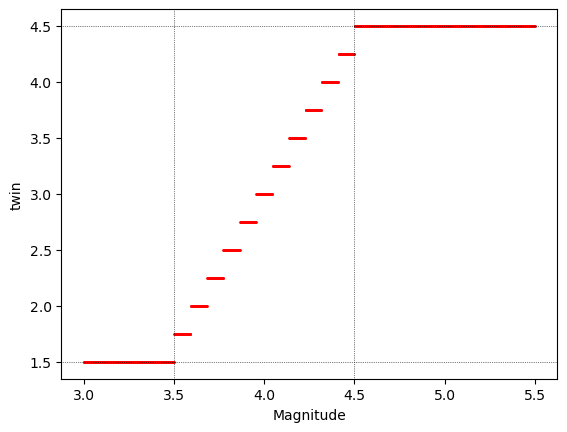

In [15]:

mags2 = np.linspace(3, 5.5, 1000)
tw_len2 = np.zeros(len(mags2))
for i in range(len(mags2)):
    tl, _ = get_time_window_length(mags2[i], min_twin, max_twin, M_min_twin, M_max_twin, d_twin)
    tw_len2[i] = tl


plt.figure()
# plt.scatter(mags, tw_len, c='k', s=1)
plt.scatter(mags2, tw_len2, c='r', s=1)
plt.axvline(x=M_max_twin, c='k', ls=':', lw=0.5)
plt.axvline(x=M_min_twin, c='k', ls=':', lw=0.5)
plt.axhline(y=max_twin, c='k', ls=':', lw=0.5)
plt.axhline(y=min_twin, c='k', ls=':', lw=0.5)
plt.xlabel("Magnitude")
plt.ylabel("twin")
plt.show()

In [16]:
# Set some plotting constants
c_trace = 'gray'
c_noise = 'r'
c_signal = 'k'
n_plot = int(len(seismogram_paths) * plot_example_percentage)
iplot = np.random.choice(len(seismogram_paths), n_plot, replace=False)


In [25]:
df_ev.at[ee,'slat'][i]

36.27148

In [ ]:
# need variable length time window


# precompute slepian tapers
# vn, lamb = utils.dpss(nwin, nw, kspec)

# Number of time window lengths
ntwin = int((max_twin - min_twin) / d_twin + 1)
# Time window lengths
twins = np.linspace(min_twin, max_twin, ntwin)
nwins = (twins * Fs).astype(int)
nffts = (2*twins*Fs + 1).astype(int)

# Precompute slepian tapers
vn = [[]] * ntwin
lamb = [[]] * ntwin
for i in range(ntwin):
    vn[i], lamb[i] = utils.dpss(nwins[i], nw, kspec)
# vn[i], lamb[i] refer to the slepian tapers for time window length twins[i]

if phase.lower() == 'p':
    arrival = 'p_arrival'
    arrival_est = 'p_arrival_est'
    picktimes = pick_p
    tt_table = ttp
elif phase.lower() == 's':
    arrival = 's_arrival'
    arrival_est = 's_arrival_est'
    picktimes = pick_s
    tt_table = tts


pick_ev_dict = {eid: i for i, eid in enumerate(picks_ev)}
pick_st_dict = {sid: i for i, sid in enumerate(picks_st)}

ev_dict = {eid: i for i, eid in enumerate(df_ev['event_name'].values)}
st_dict = {sid: i for i, sid in enumerate(df_st['station_name'].values)}

f_resample = np.linspace(0, fN, nf)

# S1 = np.empty((len(seismogram_paths), nf), dtype=float)
# S2 = np.empty((len(seismogram_paths), nf), dtype=float)

# X1 = np.empty((len(seismogram_paths), nwin), dtype=float)
# X2 = np.empty((len(seismogram_paths), nwin), dtype=float)

# X1 = np.empty(len(seismogram_paths), dtype=object)
# X2 = np.empty(len(seismogram_paths), dtype=object)



for ee in trange(len(df_ev['event_name'].values)):
    seis_paths = df_ev.at[ee, 'seismogram_path']
    nseis = len(seis_paths)

    # Get the event magnitude 
    emag = df_ev.at[ee, 'emag']

    elat = df_ev.at[ee, 'elat']
    elon = df_ev.at[ee, 'elon']
    edep = df_ev.at[ee, 'edep']

    origin_dt = df_ev.at[ee, 'etime'].to_datetime64()

    S1 = np.empty((nseis, nf), dtype=float)
    S2 = np.empty((nseis, nf), dtype=float)

    X1 = np.empty(nseis, dtype=object)
    X2 = np.empty(nseis, dtype=object)

    bad_records = []

    for i, seis_path in enumerate(seis_paths): 
        ev_id = df_ev.at[ee, 'event_name']
        st_id = df_ev.at[ee, 'station_name'][i]
        sloc = '.'.join(st_id.split('.')[:-1])

        # Read the seismogram with obspy, make a few checks
        st = read(seis_path, format="MSEED", check_compression=False)
        assert len(st) == 1
        tr = st[0]
        assert st_id == tr.id, f"Seismogram name does not match stored data: {st_id} != {tr.id}"

        # Store relevant indices to the df_ev and df_st dataframes
        # iev = ev_dict[ev_id]
        # ist = st_dict[st_id]

        # Resample if necessary
        if tr.stats.sampling_rate != Fs:
            if tr.stats.sampling_rate == Fs * 2:
                tr = tr.decimate(2)
            else:
                tr = tr.resample(Fs)
        


        # Get the time window and index
        twin_varying, itwin = get_time_window_length(emag, min_twin, max_twin, M_min_twin, M_max_twin, d_twin)
        
        # Get the catalog pick if one exists
        t_pick = picktimes[pick_ev_dict[ev_id], pick_st_dict[sloc]]

        # If no pick, estimate traveltime from event-station distance
        if t_pick == 0.0:

            slat = df_ev.at[ee,'slat'][i]
            slon = df_ev.at[ee,'slon'][i]
            sele = df_ev.at[ee,'sele'][i]

            rec_dist = geo_distance(elat, elon, slat, slon)
            depth = edep + sele * 0.001

            # Sometimes depth is negative, this prevents an error
            if depth <= 0.0: depth = 0.0001

            t_pick = get_pick_estimate(X, Y, tt_table, rec_dist, depth)

        

        # Compute time between origin and starttime (positive if starttime before origin)
        tdif = (origin_dt - np.datetime64(tr.stats.starttime)).astype(float)*1E-9

        # Some records start after origin - these are likely unusable, so discard.
        if tdif < 0:
            bad_records.append(i)
            continue


        # Time array, relative to origin time
        t = tr.times() - tdif

        # Determine first and last indices of signal window
        is0 = np.argmin(np.abs((t) - (t_pick + tbuf)))
        is1 = is0 + int(twin_varying / tr.stats.delta)

        # Determine first and last indices of noise window, immediately preceding signal window
        in1 = is0
        in0 = in1 - int(twin_varying / tr.stats.delta)

        # Extract signal and noise windows
        x2 = tr.data[is0:is1]
        x1 = tr.data[in0:in1]

        t2 = t[is0:is1]
        t1 = t[in0:in1]

        # If either window is too short, discard
        if (len(x2) * tr.stats.delta < twin_varying) | (len(x1) * tr.stats.delta < twin_varying):
            bad_records.append(i)
            continue
        

        #### SPECTRUM COMPUTATION ####
        # first method, simple
        # f_signal, s2 = mtspec.MTSpec(x2, nw=nw, kspec=kspec, dt=tr.stats.delta, nfft=int(2*(is1-is0))).rspec()
        # f_noise, s1 = mtspec.MTSpec(x1, nw=nw, kspec=kspec, dt=tr.stats.delta, nfft=int(2*(is1-is0))).rspec()

        # Direct use of mtspec functions, muuuch faster
        f2, s2_orig = mtspec_helper(x2, nw=nw, kspec=kspec, dt=tr.stats.delta, nfft=nffts[itwin], iadapt=iadapt, vn=vn[itwin], lamb=lamb[itwin])
        f1, s1_orig = mtspec_helper(x1, nw=nw, kspec=kspec, dt=tr.stats.delta, nfft=nffts[itwin], iadapt=iadapt, vn=vn[itwin], lamb=lamb[itwin])


        # Interpolate noise and signal to desired frequency resolution
        if len(s2_orig) != len(f_resample):
            s2 = np.interp(f_resample, f2, s2_orig)
            s1 = np.interp(f_resample, f1, s1_orig)
        else:
            s2 = s2_orig
            s1 = s1_orig
        
        assert len(s2) == len(f_resample)

        S1[i, :] = s1
        S2[i, :] = s2

        # X1[i, :] = x1
        # X2[i, :] = x2

        X1[i] = x1
        X2[i] = x2

        # Plot examples
        if plot_example_spectra:
            if i in iplot:
            # if itwin >0:
                
                # redo pick times for plotting, since some aren't estimated
                t_pick_actual = picktimes[pick_ev_dict[ev_id], pick_st_dict[sloc]]
                rec_dist = geo_distance(
                    df_ev.at[ee, 'elat'], 
                    df_ev.at[ee, 'elon'], 
                    df_ev.at[ee, 'slat'][i], 
                    df_ev.at[ee, 'slon'][i])
                t_est_pick = get_pick_estimate(X, Y, tt_table, rec_dist, abs(df_ev.at[ee, 'edep']) + 0.00001)
                if t_pick_actual == 0.0: t_pick_actual = -99.0

                fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
                ax1.axvline(x=0, c='k', lw=1, ls='--')

                if t_pick_actual != -99.0: ax1.axvline(x=t_pick_actual, c=c_signal, lw=1, label='Catalog pick')
                ax1.axvline(x=t_est_pick, c=c_signal, lw=1, ls=':', label='Estimated pick')

                ax1.plot(t, tr.data, c=c_trace, lw=0.5)
                ax1.plot(t2, x2, c=c_signal, lw=1, label='Signal')
                ax1.plot(t1, x1, c=c_noise, lw=1, label='Noise')

                xlim = [-1, t_pick + 10 + twin_varying]
                ax1.set_xlim(xlim)
                fig.suptitle(f"{tr.id} | {ev_id} | M{df_ev.at[ee, 'emag']:.2f} | {rec_dist:.2f} km | {tr.stats.sampling_rate:.2f} Hz")


                ax2.loglog(f_resample, s2, c=c_signal, lw=1, label='Signal')
                ax2.loglog(f_resample, s1, c=c_noise, lw=1, label='Noise')

                ax2.loglog(f2, s2_orig, c=c_signal, lw=1, ls=':')
                ax2.loglog(f1, s1_orig, c=c_noise, lw=1, ls=':')

                if tr.stats.sampling_rate < 101:
                    ax2.set_xlim([0.1, 40])
                elif tr.stats.sampling_rate < 201:
                    ax2.set_xlim([0.1, 80])


                ax1.legend()
                ax2.legend()
                ax1.set_xlabel('Time relative to origin (s)')
                ax1.set_ylabel('Amplitude')
                ax2.set_xlabel('Frequency (Hz)')
                ax2.set_ylabel('Spectral amplitude')
                ax2.set_xticks([0.1, 0.3, 1, 3, 10, 30])
                ax2.set_xticklabels([0.1, 0.3, 1, 3, 10, 30])

                plt.tight_layout()

                plt.savefig(f"{figure_save_dir}{ev_id}_{tr.id}_M{emag:.2f}_{rec_dist:.1f}km.png")
                plt.close()
    
    # bad records
    stnames = np.array(df_ev.at[ee, 'station_name'])

    msk = np.ones(len(stnames), dtype=bool)
    msk[bad_records] = False

    df_spec = pd.DataFrame(
        {
            'event_name': df_ev.at[ee, 'event_name'],
            'station_name': [stnames],
            'x1': [X1[msk]],
            'x2': [X2[msk]],
            's1': [S1[msk]],
            's2': [S2[msk]]
        })
    # save as pickle
    df_spec.to_pickle(f"{spectra_save_dir}{df_ev.at[ee, 'event_name']}.pkl")


df_spectra = pd.DataFrame()
df_spectra['event_name'] = event_names
df_spectra['station_name'] = station_names
df_spectra['x1'] = list(X1)
df_spectra['x2'] = list(X2)
df_spectra['s1'] = list(S1)
df_spectra['s2'] = list(S2)
df_spectra = df_spectra.drop(bad_records).reset_index(drop=True)

# write df_spectra as pickle
df_spectra.to_pickle(f"{spectra_save_dir}{phase.lower()}_spectra.pkl")

 68%|██████▊   | 8769/12943 [3:48:12<2:02:37,  1.76s/it]/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/multitaper/utils.py:877: RuntimeWarning: invalid value encountered in divide
  wt      = np.minimum(wt1/wt2,1.0)
 87%|████████▋ | 11213/12943 [22:44:42<3:30:33,  7.30s/it]      


KeyboardInterrupt: 

In [63]:
stnames = np.array(df_ev.at[ee, 'station_name'])

msk = np.ones(len(stnames), dtype=bool)
msk[bad_records] = False


In [68]:
stnames = np.array(df_ev.at[ee, 'station_name'])

msk = np.ones(len(stnames), dtype=bool)
msk[bad_records] = False

df_spec = pd.DataFrame(
    {
        'event_name': df_ev.at[ee, 'event_name'],
        'station_name': [stnames],
        'x1': [X1[msk]],
        'x2': [X2[msk]],
        's1': [S1[msk]],
        's2': [S2[msk]]
    })
# save as pickle
df_spec.to_pickle(f"{spectra_save_dir}{df_ev.at[ee, 'event_name']}.pkl")

In [71]:
df_spec = pd.DataFrame(
    {
        'event_name': df_ev.at[ee, 'event_name'],
        'station_name': [df_ev.at[ee, 'station_name']],
        'x1': [X1],
        'x2': [X2],
        's1': [S1],
        's2': [S2]
    })
df_spec.to_pickle(f"{spectra_save_dir}{df_ev.at[ee, 'event_name']}.pkl")

In [ ]:
df_spec = pd.DataFrame(
    {
        'event_name': df_ev.at[ee, 'event_name'],
        'station_name': df_ev.at[ee, 'station_name'],
        'x1': list(X1),
        'x2': list(X2),
        's1': list(S1),
        's2': list(S2)
    })

NameError: name 'df_spec' is not defined

In [ ]:
df_spectra

In [ ]:
# choose 10 random rows in df, loop over each, make plot of signal spectrum (s2) and noise spectrum (s1)
iplot = np.random.choice(len(df), 10, replace=False)

for i in iplot:
    fig, ax1 = plt.subplots(1,1, figsize=(5,5))
    ax1.loglog(f_resample, df_spectra.loc[i, 's2'], c=c_signal, lw=1, label='Signal')
    ax1.loglog(f_resample, df_spectra.loc[i, 's1'], c=c_noise, lw=1, label='Noise')
    ax1.set_xlim([0.1, 40])
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Spectral amplitude')
    ax1.set_xticks([0.1, 0.3, 1, 3, 10, 30])
    ax1.set_xticklabels([0.1, 0.3, 1, 3, 10, 30])
    ax1.legend()
    plt.show()